# Clase 10

Ejercicio #1: Genera 100 puntos sobre unas coordenadas (x,y), que se ajusten a la funcion y = mx + b, con un grado de dispersion sobre esta recta

Puntos generados: 100
Recta original: y = 2.0x + 1.0; desviación del ruido = 1.5


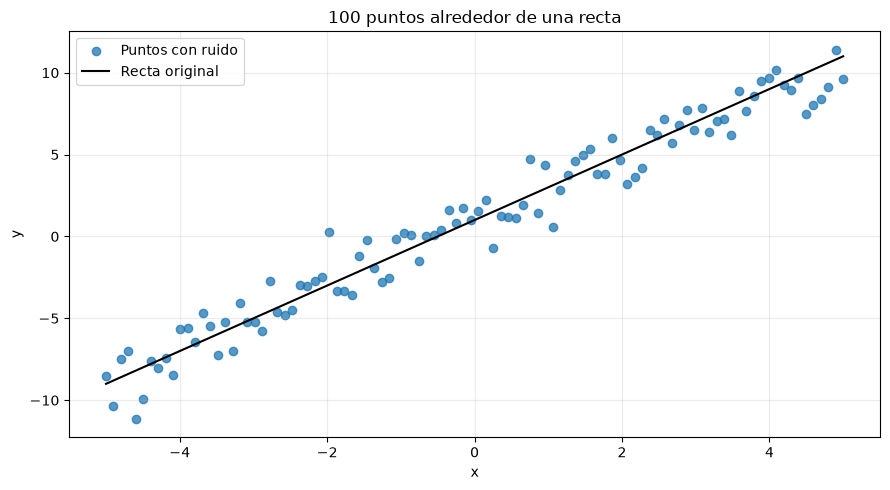

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla fija para poder reproducir los mismos 100 puntos.
rng = np.random.default_rng(42)
n_puntos = 100
m = 2.0
b = 1.0
sigma = 1.5  # Desviación estándar del ruido: controla la dispersión.

x = np.linspace(-5, 5, n_puntos)
y_recta = m * x + b
ruido = rng.normal(loc=0.0, scale=sigma, size=n_puntos)
y_generado = y_recta + ruido

print(f"Puntos generados: {n_puntos}")
print(f"Recta original: y = {m}x + {b}; desviación del ruido = {sigma}")

plt.figure(figsize=(9, 5))
plt.scatter(x, y_generado, alpha=0.75, label="Puntos con ruido")
plt.plot(x, y_recta, color="black", label="Recta original")
plt.xlabel("x")
plt.ylabel("y")
plt.title("100 puntos alrededor de una recta")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Ejercicio #2: Usar una neurona artificial de 5 entradas, de forma iteativa, para encontrar los mejores w_i que acercan y_estimado al y_generado. Usar como funcion de activacion on/off

y = f(sum(w_i * x_i)) 

Se espera que falle, que tenga mal resultado

### Elección de las entradas y del aprendizaje

El enunciado proporciona una sola coordenada `x`, pero pide cinco entradas. Usaremos `[1, z, z², z³, z⁴]`, donde `z` es `x` centrada y escalada al intervalo [-1, 1]. La entrada constante representa el sesgo; en total hay exactamente cinco pesos.

La activación es un escalón: devuelve **0** si la suma ponderada es negativa y **1** si es mayor o igual a cero. Se mantiene `y_generado` como objetivo continuo, tal como pide el ejercicio.

Para ilustrar el intento de aprendizaje, actualizamos los pesos iterativamente con una regla de corrección del error inspirada en el perceptrón. Esta adaptación a objetivos continuos es **heurística**: no es descenso de gradiente a través del escalón y no tiene garantía de convergencia. Guardamos los mejores pesos **observados**, sin afirmar que sean el óptimo global.


Cinco pesos encontrados: [ 0.0162  0.1247 -0.0223 -0.03   -0.0429]
Mejor época observada: 3 de 1000
ECM inicial: 33.0192
Mejor ECM de la neurona on/off: 28.7498
Cota inferior del ECM para cualquier salida binaria: 28.7159
ECM de la recta generadora (referencia conocida): 1.3494
Valores predichos: [0. 1.]


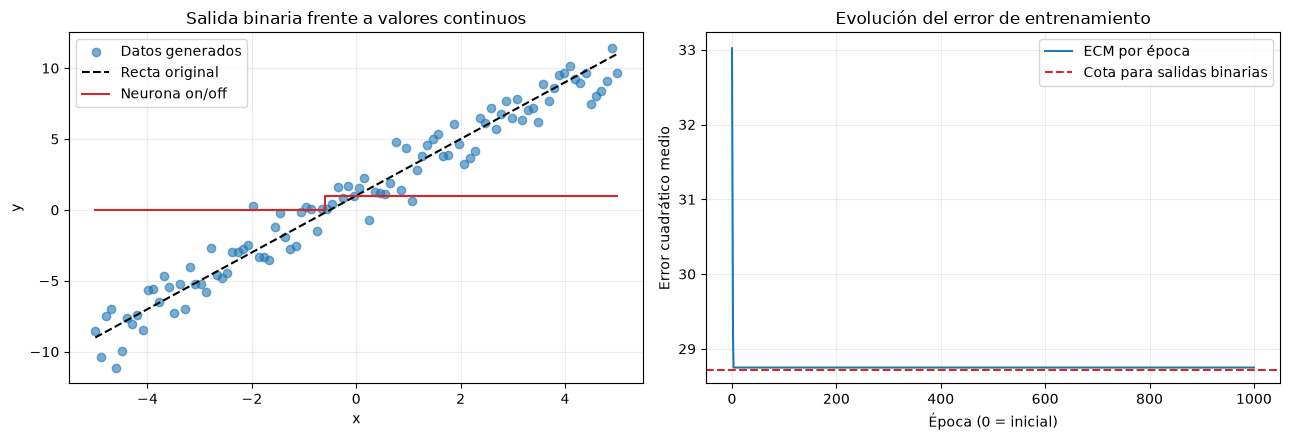

In [4]:
# Cinco entradas por punto: [1, z, z², z³, z⁴].
# La entrada constante permite aprender un sesgo dentro de los cinco pesos.
z = (x - x.mean()) / np.max(np.abs(x - x.mean()))
X = np.column_stack([np.ones_like(z), z, z**2, z**3, z**4])

def activacion_on_off(suma):
    """Devuelve 1 si la suma es mayor o igual a cero; 0 en otro caso."""
    return (np.asarray(suma) >= 0).astype(float)

rng_pesos = np.random.default_rng(7)
w = rng_pesos.normal(0.0, 0.1, size=5)
tasa_aprendizaje = 0.01
epocas = 1000

prediccion_inicial = activacion_on_off(X @ w)
ecm_inicial = np.mean((y_generado - prediccion_inicial) ** 2)
mejores_w = w.copy()
mejor_ecm = ecm_inicial
mejor_epoca = 0
historial_ecm = [ecm_inicial]

for epoca in range(1, epocas + 1):
    y_actual = activacion_on_off(X @ w)
    error = y_generado - y_actual

    # Regla heurística inspirada en el perceptrón, aplicada por lotes.
    # NO es el gradiente del ECM de la neurona con escalón:
    # el escalón tiene derivada cero salvo en el umbral, donde no existe.
    w += tasa_aprendizaje * (X.T @ error) / n_puntos

    y_actual = activacion_on_off(X @ w)
    ecm = np.mean((y_generado - y_actual) ** 2)
    historial_ecm.append(ecm)
    if ecm < mejor_ecm:
        mejor_ecm = ecm
        mejores_w = w.copy()
        mejor_epoca = epoca

# Conservamos los mejores pesos observados, incluido el estado inicial.
y_estimado = activacion_on_off(X @ mejores_w)

# Cota inferior: permitir elegir libremente 0 o 1 para cada observación.
# Ninguna neurona con salida binaria puede obtener un ECM menor que esta cota.
cota_ecm_binaria = np.mean(np.minimum(y_generado**2, (y_generado - 1)**2))
ecm_recta = np.mean((y_generado - y_recta) ** 2)

print("Cinco pesos encontrados:", np.round(mejores_w, 4))
print(f"Mejor época observada: {mejor_epoca} de {epocas}")
print(f"ECM inicial: {ecm_inicial:.4f}")
print(f"Mejor ECM de la neurona on/off: {mejor_ecm:.4f}")
print(f"Cota inferior del ECM para cualquier salida binaria: {cota_ecm_binaria:.4f}")
print(f"ECM de la recta generadora (referencia conocida): {ecm_recta:.4f}")
print("Valores predichos:", np.unique(y_estimado))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(x, y_generado, alpha=0.6, label="Datos generados")
axes[0].plot(x, y_recta, color="black", linestyle="--", label="Recta original")
axes[0].step(x, y_estimado, where="mid", color="tab:red", label="Neurona on/off")
axes[0].set(xlabel="x", ylabel="y", title="Salida binaria frente a valores continuos")
axes[0].legend()
axes[1].plot(historial_ecm, label="ECM por época")
axes[1].axhline(cota_ecm_binaria, color="tab:red", linestyle="--", label="Cota para salidas binarias")
axes[1].set(xlabel="Época (0 = inicial)", ylabel="Error cuadrático medio", title="Evolución del error de entrenamiento")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Ejercicio 3: En el punto anterior, incluir como funcion de costo el MSE (y_real vs y_estimado), cambiar la funcion de activacion a sigmoide. Incluir offset y reoartir la estimacion de la recta. proporciuonar los mejores w_i


w_1 (entrada z^1) = 1.634319
w_2 (entrada z^2) = 0.347321
w_3 (entrada z^3) = 0.834464
w_4 (entrada z^4) = -0.421937
w_5 (entrada z^5) = 0.012052
Offset = 0.155434
MSE inicial = 35.251836
Mejor MSE con sigmoide reescalada = 1.237545
MSE anterior con on/off = 28.749823


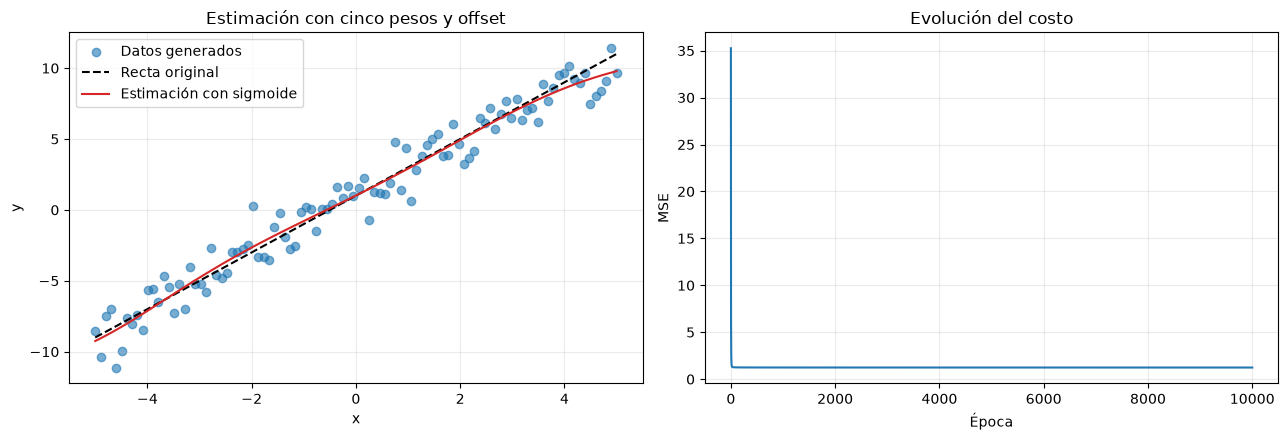

In [5]:
# Cinco entradas y un offset independiente (sesgo).
# La constante de X se sustituye por z**5 para no duplicar el sesgo.
X_sigmoide = np.column_stack([z, z**2, z**3, z**4, z**5])

# Reescalamos la salida sigmoide al rango de y para estimar valores continuos.
y_min = y_generado.min()
y_rango = y_generado.max() - y_min

def sigmoide(suma):
    return 1.0 / (1.0 + np.exp(-np.clip(suma, -500, 500)))

rng_sigmoide = np.random.default_rng(7)
w_sigmoide = rng_sigmoide.normal(0.0, 0.1, size=5)
offset_sigmoide = 0.0
tasa_sigmoide = 0.01
epocas_sigmoide = 10000
historial_mse_sigmoide = []
mejor_mse_sigmoide = np.inf

# Descenso de gradiente del MSE en las unidades originales de y.
for epoca in range(epocas_sigmoide + 1):
    salida = sigmoide(X_sigmoide @ w_sigmoide + offset_sigmoide)
    y_estimado_sigmoide = y_min + y_rango * salida
    error = y_estimado_sigmoide - y_generado
    mse_actual = np.mean(error**2)
    historial_mse_sigmoide.append(mse_actual)

    if mse_actual < mejor_mse_sigmoide:
        mejor_mse_sigmoide = mse_actual
        mejores_w_sigmoide = w_sigmoide.copy()
        mejor_offset_sigmoide = offset_sigmoide

    if epoca == epocas_sigmoide:
        break

    # Regla de la cadena: MSE -> reescalado -> sigmoide -> pesos y offset.
    delta = (2.0 / len(y_generado)) * error * y_rango * salida * (1 - salida)
    w_sigmoide -= tasa_sigmoide * (X_sigmoide.T @ delta)
    offset_sigmoide -= tasa_sigmoide * delta.sum()

w_sigmoide = mejores_w_sigmoide.copy()
offset_sigmoide = mejor_offset_sigmoide
y_estimado_sigmoide = y_min + y_rango * sigmoide(X_sigmoide @ w_sigmoide + offset_sigmoide)
mse_sigmoide = np.mean((y_generado - y_estimado_sigmoide)**2)

for i, peso in enumerate(w_sigmoide, start=1):
    print(f"w_{i} (entrada z^{i}) = {peso:.6f}")
print(f"Offset = {offset_sigmoide:.6f}")
print(f"MSE inicial = {historial_mse_sigmoide[0]:.6f}")
print(f"Mejor MSE con sigmoide reescalada = {mse_sigmoide:.6f}")
print(f"MSE anterior con on/off = {mejor_ecm:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(x, y_generado, alpha=0.6, label="Datos generados")
axes[0].plot(x, y_recta, "k--", label="Recta original")
axes[0].plot(x, y_estimado_sigmoide, color="tab:red", label="Estimación con sigmoide")
axes[0].set(xlabel="x", ylabel="y", title="Estimación con cinco pesos y offset")
axes[0].legend()
axes[1].plot(historial_mse_sigmoide)
axes[1].set(xlabel="Época", ylabel="MSE", title="Evolución del costo")
for ax in axes:
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
